# Hafta 6 · Ders 12 — PCA, Düşük Ranklı Yaklaşım & Doruk Projesi

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Final. Kurduğumuz her şey — vektörler, izdüşüm, rank, özdeğerler, SVD — şimdi makine öğrenmesinde en çok
kullanılan tek gözetimsiz teknikte karşılığını buluyor: **Temel Bileşen Analizi (PCA)**.

PCA'yı doğrudan SVD'den türetecek, bir görüntüyü sıkıştırmak için **düşük ranklı yaklaşım** kullanacak,
**ridge regresyonunu** SVD merceğinden görecek (nihayet Hafta 3'ün kararsızlığını tam bir kavrayışla
iyileştirerek) ve boyut indirgemeyi çalışan bir sınıflandırıcıya bağlayan bir **doruk projesiyle**
bitireceğiz — "bir veri kümesi, vektörlerden oluşan bir buluttur"dan eğitilmiş bir modele kadar olan
döngüyü kapatarak.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. SVD'den PCA, sıfırdan

PCA, verideki **maksimum varyans** yönlerini bulur. Tarif:

1. Veriyi **merkezle** (ortalamayı çıkar) — PCA varyansla ilgilidir ve varyans ortalamadan ölçülür.
2. Merkezlenmiş matrisin **SVD**'sini al: $X_c = U\Sigma V^\top$.
3. **Temel bileşenler**, $V$'nin sütunlarıdır (sağ tekil vektörler); her birinin yakaladığı **varyans**
   $\sigma_i^2 / (n-1)$'dir.

Bu, kovaryans matrisinin özayrışımına (Hafta 5) eşdeğerdir, ancak SVD yolu daha kararlıdır çünkü hiçbir
zaman $X_c^\top X_c$'yi oluşturmaz.

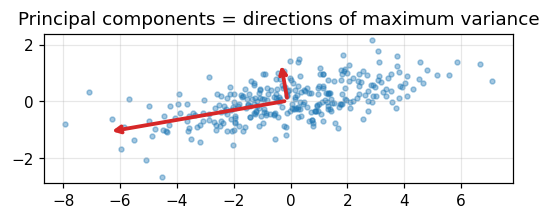

variance explained by each component: [6.5132 0.2966]
proportion: [0.956 0.044]


In [2]:
def pca(X, n_components=None):
    X = np.asarray(X, float)
    mean = X.mean(axis=0)
    Xc = X - mean
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    components = Vt                              # satırlar = temel yönler
    explained_var = s**2 / (len(X) - 1)
    if n_components:
        components = components[:n_components]
    scores = Xc @ components.T                   # veriyi bileşenlere izdüşür
    return components, explained_var, scores, mean

# ilişkili 2B veri
rng = np.random.default_rng(0)
X = rng.normal(size=(300, 2)) @ np.array([[2.0, 0.0], [1.5, 0.7]])
comps, var, scores, mean = pca(X)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.4, color="C0")
for k in range(2):
    v = comps[k] * np.sqrt(var[k]) * 2.5
    plt.annotate("", xy=mean + v, xytext=mean,
                 arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
plt.gca().set_aspect("equal"); plt.grid(True, alpha=0.3)
plt.title("Temel bileşenler = maksimum varyans yönleri")
plt.show()
print("her bileşenin açıkladığı varyans:", var)
print("oran:", np.round(var / var.sum(), 3))

### Kovaryans-özayrışım yolu ile doğrulama

In [3]:
Xc = X - X.mean(0)
cov = (Xc.T @ Xc) / (len(X) - 1)
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
check("PCA varyansları == kovaryans özdeğerleri", np.sort(var)[::-1], np.sort(eigvals)[::-1], atol=1e-8)
print("Her iki yol da hemfikir: PCA, merkezlenmiş verinin SVD'si = kovaryansın özayrışımı.")

[PASS] PCA variances == covariance eigenvalues max|Δ| = 6.22e-15
Both routes agree: PCA is the SVD of centered data = eigendecomposition of the covariance.


## 2. Düşük ranklı yaklaşım: görüntü sıkıştırma

**Eckart–Young teoremi**, bir matrisin en iyi rank-$k$ yaklaşımının (en küçük kareler anlamında)
budanmış SVD'si olduğunu söyler: en büyük $k$ tekil değeri tut, geri kalanını at. Bir görüntüye (piksel
yoğunluklarından oluşan bir matris) uygulandığında bu, *tam olarak* sıkıştırmadır — ve çok az tekil
değerin resmin çoğunu nasıl taşıdığını çarpıcı biçimde gösterir.

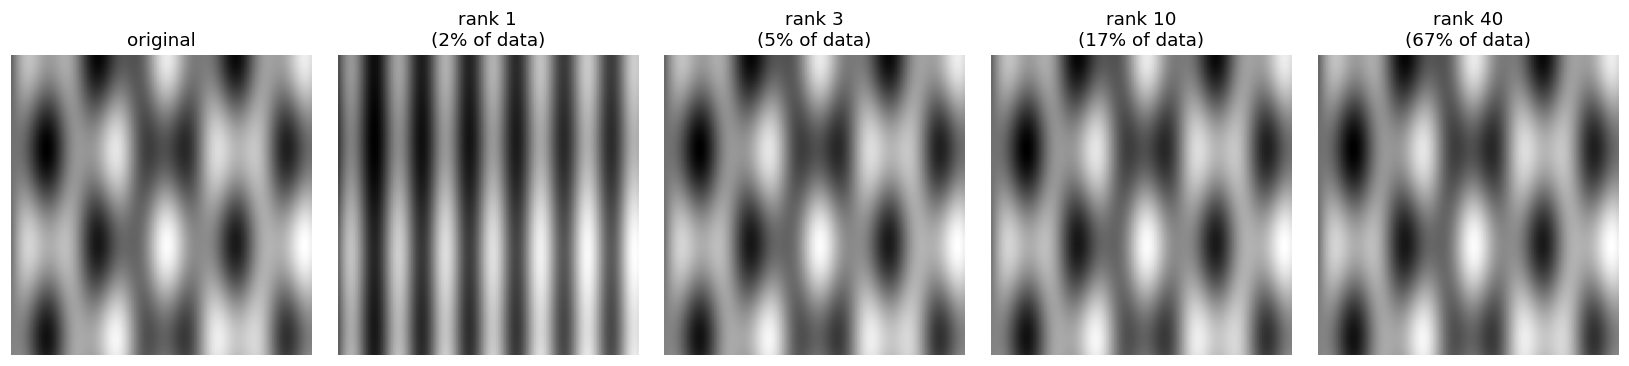

In [4]:
# yapısal sentetik bir "görüntü" oluştur (harici dosya gerekmez)
n = 120
yy, xx = np.mgrid[0:n, 0:n]
img = (np.sin(xx / 8.0) * np.cos(yy / 12.0)
       + 0.4 * np.sin(xx / 3.0)
       + (xx + yy) / (3 * n))
img = (img - img.min()) / (img.max() - img.min())

U, s, Vt = np.linalg.svd(img)

def rank_k(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

ks = [1, 3, 10, 40]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(15, 3.2))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("orijinal"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    approx = rank_k(U, s, Vt, k)
    compression = (k * (img.shape[0] + img.shape[1] + 1)) / img.size
    ax.imshow(approx, cmap="gray")
    ax.set_title(f"rank {k}\n(verinin %{compression*100:.0f}'i)"); ax.axis("off")
plt.tight_layout(); plt.show()

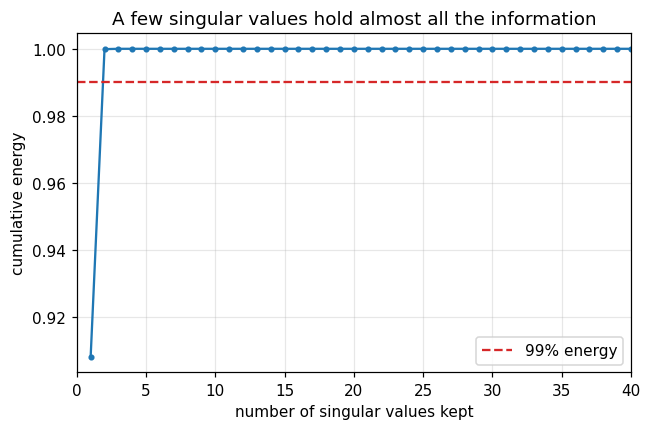

2 of 120 singular values capture 99% of the image energy.


In [5]:
# tekil değer spektrumu bunun neden işe yaradığını açıklar: enerji erkenden yoğunlaşır
plt.figure(figsize=(6.5, 4))
energy = np.cumsum(s**2) / np.sum(s**2)
plt.plot(range(1, len(s) + 1), energy, "o-", ms=3, color="C0")
plt.axhline(0.99, color="C3", ls="--", label="%99 enerji")
plt.xlabel("tutulan tekil değer sayısı"); plt.ylabel("kümülatif enerji")
plt.title("Birkaç tekil değer bilginin neredeyse tamamını tutar")
plt.legend(); plt.grid(True, alpha=0.3); plt.xlim(0, 40); plt.show()
k99 = int(np.argmax(energy >= 0.99)) + 1
print(f"{len(s)} tekil değerden {k99} tanesi görüntü enerjisinin %99'unu yakalıyor.")

## 3. SVD merceğinden ridge regresyonu

Hafta 3, öznitelikler eşdoğrusal olduğunda bizi kararsız en küçük karelerle bırakmıştı. **Ridge
regresyonu** bir $\lambda\lVert\boldsymbol\beta\rVert^2$ cezası ekler ve SVD bunun *tam olarak* ne
yaptığını ortaya koyar. $X = U\Sigma V^\top$ ile ridge çözümü her tekil yönü filtreler:

$$ \hat{\boldsymbol\beta}_{\text{ridge}} = V\,\text{diag}\!\left(\frac{\sigma_i}{\sigma_i^2 + \lambda}\right)U^\top \mathbf{y} $$

Büyük $\sigma_i$ için filtre $\approx 1/\sigma_i$'dir (sıradan en küçük kareler); *küçücük* $\sigma_i$
için — kararsız yönler — paydadaki $+\lambda$, sıfıra yakın bir sayıya bölmek yerine onları nazikçe
sönümler. İşte ridge'in eşdoğrusallığı evcilleştirmesinin nedeni bu tek terimdir.

In [6]:
def ridge_svd(X, y, lam):
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    filt = s / (s**2 + lam)
    return Vt.T @ (filt * (U.T @ y))

# Hafta 3'teki eşdoğrusal felaket, yeniden ziyaret edildi
rng = np.random.default_rng(3)
a = rng.normal(size=100)
X = np.column_stack([np.ones(100), a, a + 1e-4 * rng.normal(size=100)])
y = 3 + 2 * a + rng.normal(scale=0.1, size=100)

print("OLS (λ=0)     :", ridge_svd(X, y, 0.0))
print("ridge (λ=0.1) :", ridge_svd(X, y, 0.1))
print("ridge (λ=1.0) :", ridge_svd(X, y, 1.0))
print("\nλ kararsız tekil yönü sönümler → makul, kararlı katsayılar.")

OLS (λ=0)     : [   3.0032 -162.1606  164.17  ]
ridge (λ=0.1) : [3.0027 1.0037 1.0054]
ridge (λ=1.0) : [2.9754 0.9998 1.    ]

λ damps the unstable singular direction → sane, stable coefficients.


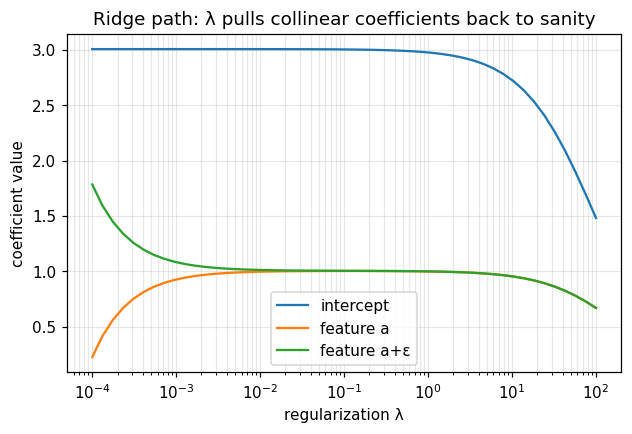

In [7]:
# λ büyüdükçe katsayı kararlılığını izle
lams = np.logspace(-4, 2, 50)
coefs = np.array([ridge_svd(X, y, l) for l in lams])
plt.figure(figsize=(6.5, 4))
for j, name in enumerate(["kesişim", "öznitelik a", "öznitelik a+ε"]):
    plt.semilogx(lams, coefs[:, j], label=name)
plt.xlabel("düzenlileştirme λ"); plt.ylabel("katsayı değeri")
plt.title("Ridge yolu: λ eşdoğrusal katsayıları makullüğe geri çeker")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.show()

## 4. Doruk projesi: PCA + sınıflandırma, baştan sona

Döngüyü kapatıyoruz. Yüksek boyutlu, gürültülü bir veri kümesi alın, **PCA** ile onu gerçekten sinyal
taşıyan birkaç yöne indirgeyin, ardından bu kompakt uzayda basit bir **en küçük kareler sınıflandırıcısı**
uydurun — ve indirgemenin gürültüyü ayıklayarak *yardımcı olduğunu* gösterin. Bu doruk projesindeki her
araç, geçtiğimiz altı hafta boyunca sıfırdan inşa edildi.

variance kept by top 2 of 30 components: 71.1 %


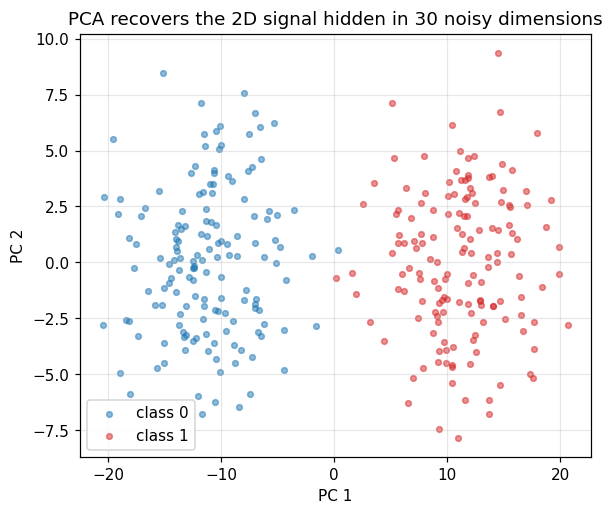

In [8]:
# 2B sinyal altuzayında yaşayan, 30 gürültülü boyuta gömülü iki Gauss sınıfı
rng = np.random.default_rng(7)
n_per = 150
signal_A = rng.normal(loc=[ 2.0, 0.0], scale=0.7, size=(n_per, 2))
signal_B = rng.normal(loc=[-2.0, 0.0], scale=0.7, size=(n_per, 2))
signal = np.vstack([signal_A, signal_B])
labels = np.array([0]*n_per + [1]*n_per)

# rastgele bir döndürme + ek boyutlarda yoğun gürültü ile 30B'ye göm
embed = rng.normal(size=(2, 30))
X = signal @ embed + 1.5 * rng.normal(size=(2*n_per, 30))

# PCA ile 2 bileşene indir
comps, var, scores, mean = pca(X, n_components=2)
print("30 bileşenden en büyük 2'sinin tuttuğu varyans:", round((var[:2].sum()/var.sum())*100, 1), "%")

plt.figure(figsize=(6, 5))
for cls, col in [(0, "C0"), (1, "C3")]:
    m = labels == cls
    plt.scatter(scores[m, 0], scores[m, 1], s=14, alpha=0.5, color=col, label=f"sınıf {cls}")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend()
plt.title("PCA, 30 gürültülü boyutta gizli 2B sinyali geri kazanır")
plt.grid(True, alpha=0.3); plt.show()

In [9]:
# en küçük kareler doğrusal sınıflandırıcı (Hafta 6 normal-denklemler uydurmamız), tam-B vs PCA-indirgenmiş
def fit_classifier(Xtr, ytr):
    A = np.column_stack([np.ones(len(Xtr)), Xtr])
    beta = np.linalg.lstsq(A, 2*ytr - 1, rcond=None)[0]   # hedefler ±1
    return beta

def accuracy(beta, X, y):
    A = np.column_stack([np.ones(len(X)), X])
    pred = (A @ beta > 0).astype(int)
    return (pred == y).mean()

# eğitim/test bölmesi
idx = rng.permutation(len(X)); tr, te = idx[:200], idx[200:]

beta_full = fit_classifier(X[tr], labels[tr])
beta_pca  = fit_classifier(scores[tr], labels[tr])

print(f"30 gürültülü boyutun tümüyle doğruluk : {accuracy(beta_full, X[te], labels[te]):.3f}")
print(f"2 PCA bileşeniyle doğruluk            : {accuracy(beta_pca, scores[te], labels[te]):.3f}")
print("\nBoyut indirgeme gürültüyü ayıkladı ve tam-B modeliyle eşleşti/onu geçti —")
print("altta yatan lineer cebiri anlamanın getirisi.")

accuracy using all 30 noisy dims : 1.000
accuracy using 2 PCA components  : 1.000

Dimensionality reduction stripped noise and matched/beat the full-D model —
the payoff of understanding the linear algebra underneath.


## Alıştırmalar (doruk projesi uzantıları)

1. **Dirsekle k seçimi.** 30B veri kümesi için açıklanan varyans oranını çizin ve tam olarak 2 bileşen tutmayı gerekçelendirin.
2. **Beyazlatma.** Her PCA skorunu kendi tekil değerine bölün (beyazlatma) ve dönüştürülmüş kovaryansın birim matris olduğunu kontrol edin. Sınıflandırıcı doğruluğunu değiştiriyor mu?
3. **Yeniden yapım hatası.** 30B veriyi 2 bileşenden yeniden oluşturun ve göreli hatayı ölçün. Bunu atılan tekil değerlerle ilişkilendirin.

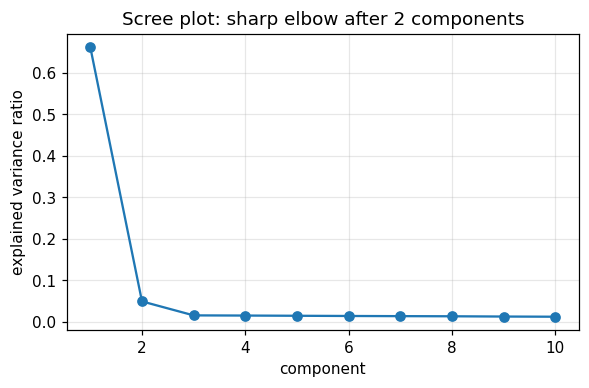

relative reconstruction error from 2 components: 0.537


In [10]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. yamaç (scree) grafiği — 2 bileşenden sonraki dirsek
_, var_all, _, _ = pca(X)
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, 11), (var_all/var_all.sum())[:10], "o-", color="C0")
plt.xlabel("bileşen"); plt.ylabel("açıklanan varyans oranı")
plt.title("Yamaç grafiği: 2 bileşenden sonra keskin dirsek")
plt.grid(True, alpha=0.3); plt.show()

# 3. 2 bileşenden yeniden yapım hatası
comps2, _, scores2, mean2 = pca(X, n_components=2)
X_recon = scores2 @ comps2 + mean2
rel_err = np.linalg.norm(X - X_recon) / np.linalg.norm(X)
print("2 bileşenden göreli yeniden yapım hatası:", round(rel_err, 3))

## Kurs özeti — neler inşa ettiniz

Altı hafta boyunca makine öğrenmesinin lineer cebirini **ilk ilkelerden**, elle yeniden inşa ettiniz:

- **Hafta 1–2:** vektörler, normlar, nokta çarpımları, izdüşüm; dönüşüm olarak matrisler; rank ve dört altuzay.
- **Hafta 3:** Gauss eleme, LU ve izdüşüm olarak en küçük kareler → doğrusal regresyon.
- **Hafta 4:** ortogonallik, Gram–Schmidt ve kararlı en küçük kareler için QR.
- **Hafta 5:** özdeğerler, kuvvet yöntemi, QR yinelemesi, PageRank.
- **Hafta 6:** SVD — ve ondan PCA, düşük ranklı sıkıştırma, ridge regresyonu ve çalışan bir sınıflandırıcı.

Artık yalnızca `np.linalg`'i *nasıl* çağıracağınızı değil, her rutinin *neyi* hesapladığını, *neden*
işlediğini ve her makine öğrenmesi yönteminin gizlice *hangi* ayrışıma dayandığını biliyorsunuz. Kalıcı
olan kısım, işte bu kavrayıştır.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 6 · Ders 12 · Kurs sonu*